In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler

In [ ]:
df = pd.read_csv("BankChurners.csv")

In [ ]:
df.head(50)

,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,...,12691.0,777,11914.0,1.335,1144,42,1.625,0.061,0.000093,0.999910
1,818770008,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,...,8256.0,864,7392.0,1.541,1291,33,3.714,0.105,0.000057,0.999940
2,713982108,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,...,3418.0,0,3418.0,2.594,1887,20,2.333,0.000,0.000021,0.999980
3,769911858,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,...,3313.0,2517,796.0,1.405,1171,20,2.333,0.760,0.000134,0.999870
4,709106358,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,...,4716.0,0,4716.0,2.175,816,28,2.500,0.000,0.000022,0.999980
5,713061558,Existing Customer,44,M,2,Graduate,Married,$40K - $60K,Blue,36,...,4010.0,1247,2763.0,1.376,1088,24,0.846,0.311,0.000055,0.999940
6,810347208,Existing Customer,51,M,4,Unknown,Married,$120K +,Gold,46,...,34516.0,2264,32252.0,1.975,1330,31,0.722,0.066,0.000123,0.999880
7,818906208,Existing Customer,32,M,0,High School,Unknown,$60K - $80K,Silver,27,...,29081.0,1396,27685.0,2.204,1538,36,0.714,0.048,0.000086,0.999910
8,710930508,Existing Customer,37,M,3,Uneducated,Single,$60K - $80K,Blue,36,...,22352.0,2517,19835.0,3.355,1350,24,1.182,0.113,0.000045,0.999960
9,719661558,Existing Customer,48,M,2,Graduate,Single,$80K - $120K,Blue,36,...,11656.0,1677,9979.0,1.524,1441,32,0.882,0.144,0.000303,0.999700


In [ ]:
df.shape

(10127, 23)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 23 columns):
 #   Column                                                                                                                              Non-Null Count  Dtype  
---  ------                                                                                                                              --------------  -----  
 0   CLIENTNUM                                                                                                                           10127 non-null  int64  
 1   Attrition_Flag                                                                                                                      10127 non-null  object 
 2   Customer_Age                                                                                                                        10127 non-null  int64  
 3   Gender                                                                           

In [ ]:
df.isnull().sum()

,0
CLIENTNUM,0
Attrition_Flag,0
Customer_Age,0
Gender,0
Dependent_count,0
Education_Level,0
Marital_Status,0
Income_Category,0
Card_Category,0
Months_on_book,0


In [ ]:
df.columns

Index(['CLIENTNUM', 'Attrition_Flag', 'Customer_Age', 'Gender',
       'Dependent_count', 'Education_Level', 'Marital_Status',
       'Income_Category', 'Card_Category', 'Months_on_book',
       'Total_Relationship_Count', 'Months_Inactive_12_mon',
       'Contacts_Count_12_mon', 'Credit_Limit', 'Total_Revolving_Bal',
       'Avg_Open_To_Buy', 'Total_Amt_Chng_Q4_Q1', 'Total_Trans_Amt',
       'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1', 'Avg_Utilization_Ratio',
       'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1',
       'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2'],
      dtype='object')

In [ ]:
df.columns = df.columns.str.lower()
df.columns = df.columns.str.replace(' ', '_')

In [ ]:
df = df.drop(columns=[
    df.columns[-1],
    df.columns[-2]
])

In [ ]:
df.columns

Index(['clientnum', 'attrition_flag', 'customer_age', 'gender',
       'dependent_count', 'education_level', 'marital_status',
       'income_category', 'card_category', 'months_on_book',
       'total_relationship_count', 'months_inactive_12_mon',
       'contacts_count_12_mon', 'credit_limit', 'total_revolving_bal',
       'avg_open_to_buy', 'total_amt_chng_q4_q1', 'total_trans_amt',
       'total_trans_ct', 'total_ct_chng_q4_q1', 'avg_utilization_ratio'],
      dtype='object')

In [ ]:
df.describe()

,clientnum,customer_age,dependent_count,months_on_book,total_relationship_count,months_inactive_12_mon,contacts_count_12_mon,credit_limit,total_revolving_bal,avg_open_to_buy,total_amt_chng_q4_q1,total_trans_amt,total_trans_ct,total_ct_chng_q4_q1,avg_utilization_ratio
count,1.012700e+04,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000
mean,7.391776e+08,46.325960,2.346203,35.928409,3.812580,2.341167,2.455317,8631.953698,1162.814061,7469.139637,0.759941,4404.086304,64.858695,0.712222,0.274894
std,3.690378e+07,8.016814,1.298908,7.986416,1.554408,1.010622,1.106225,9088.776650,814.987335,9090.685324,0.219207,3397.129254,23.472570,0.238086,0.275691
min,7.080821e+08,26.000000,0.000000,13.000000,1.000000,0.000000,0.000000,1438.300000,0.000000,3.000000,0.000000,510.000000,10.000000,0.000000,0.000000
25%,7.130368e+08,41.000000,1.000000,31.000000,3.000000,2.000000,2.000000,2555.000000,359.000000,1324.500000,0.631000,2155.500000,45.000000,0.582000,0.023000
50%,7.179264e+08,46.000000,2.000000,36.000000,4.000000,2.000000,2.000000,4549.000000,1276.000000,3474.000000,0.736000,3899.000000,67.000000,0.702000,0.176000
75%,7.731435e+08,52.000000,3.000000,40.000000,5.000000,3.000000,3.000000,11067.500000,1784.000000,9859.000000,0.859000,4741.000000,81.000000,0.818000,0.503000
max,8.283431e+08,73.000000,5.000000,56.000000,6.000000,6.000000,6.000000,34516.000000,2517.000000,34516.000000,3.397000,18484.000000,139.000000,3.714000,0.999000


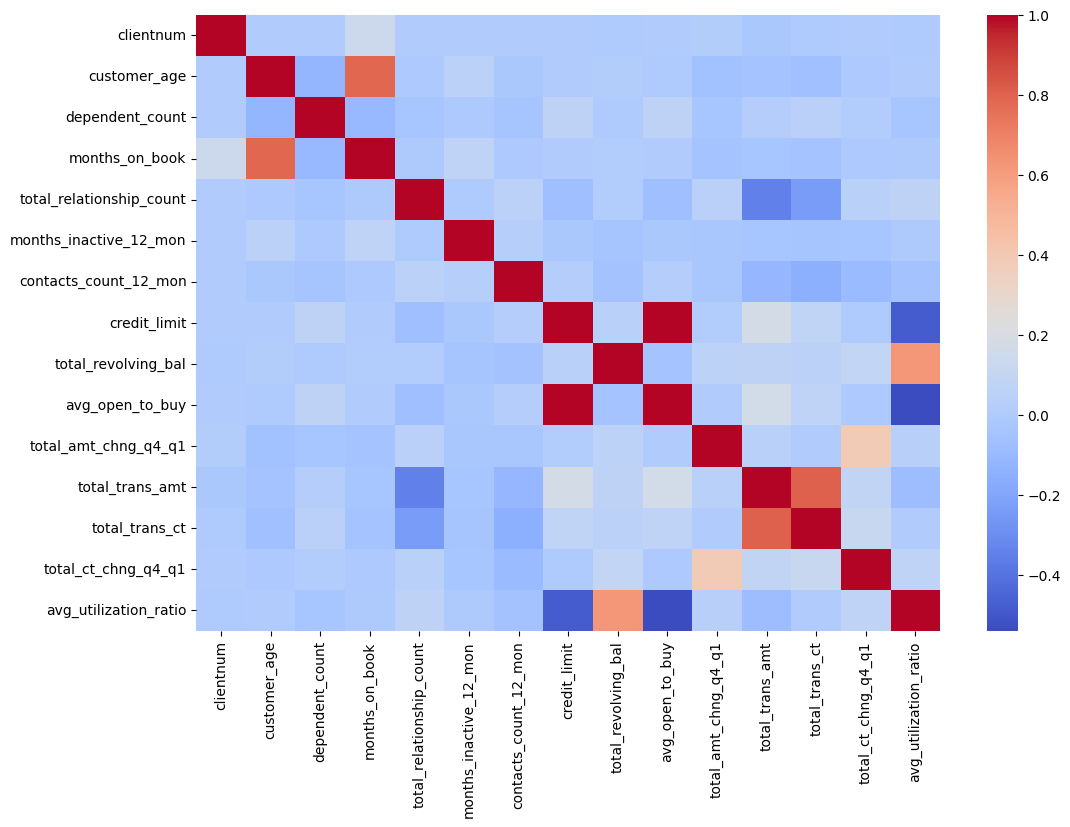

In [ ]:
# 1. which variables move together?
# 2. Any strong relationship?
plt.figure(figsize=(12,8))

sns.heatmap(
    df.select_dtypes(include=np.number).corr(),
    cmap='coolwarm'
)

plt.show()

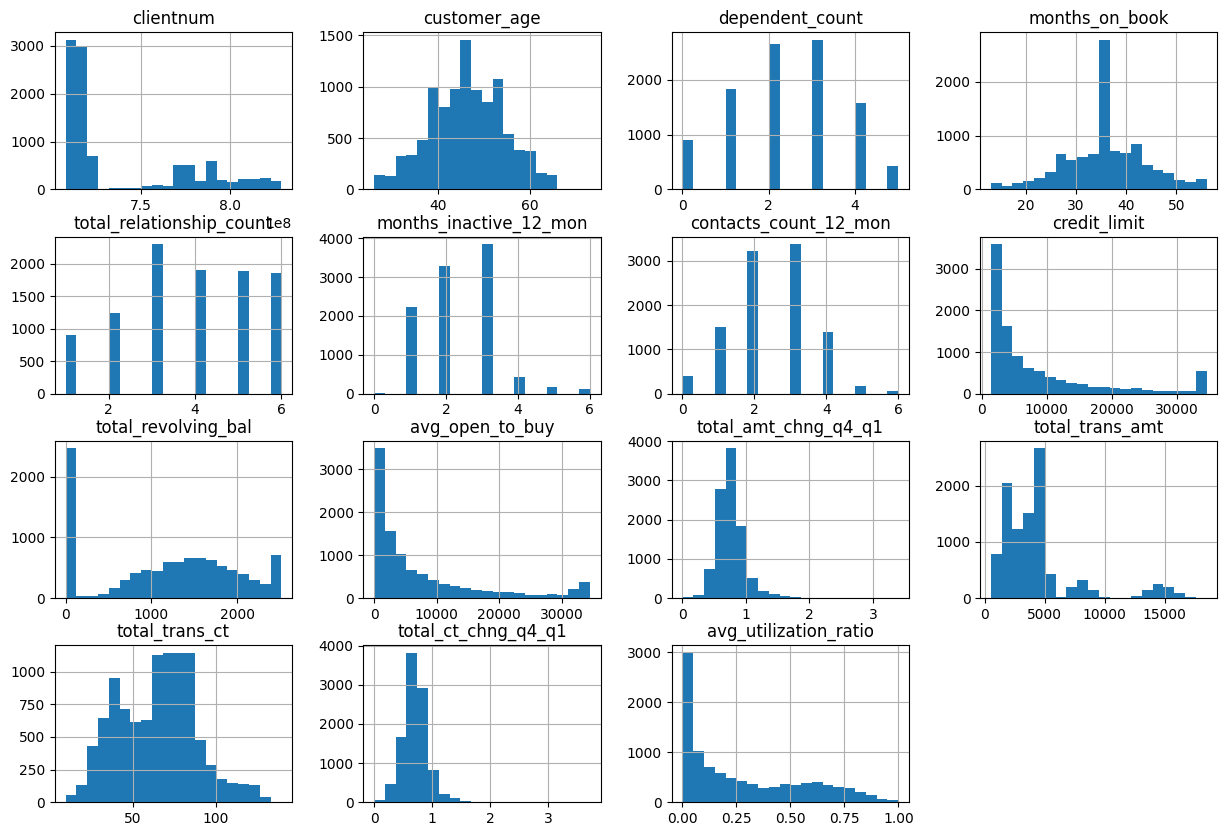

In [ ]:
df.hist(
    figsize=(15,10),
    bins=20
)

plt.show()

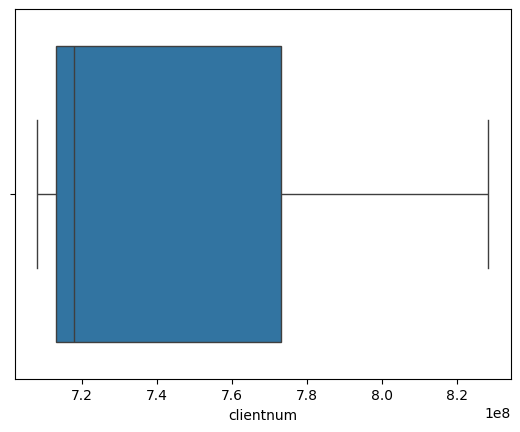

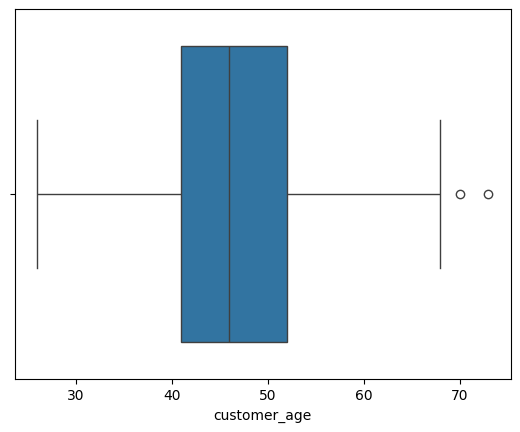

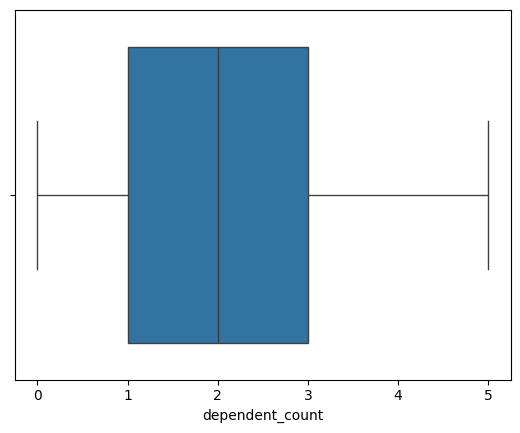

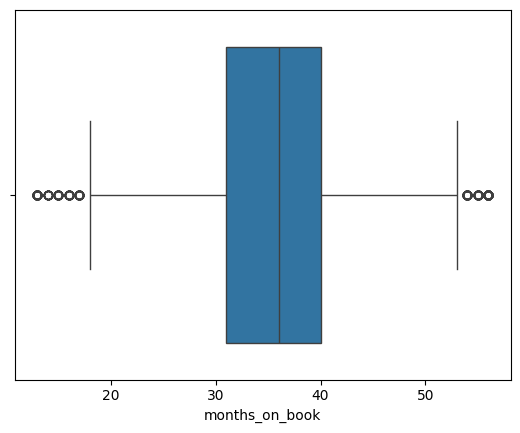

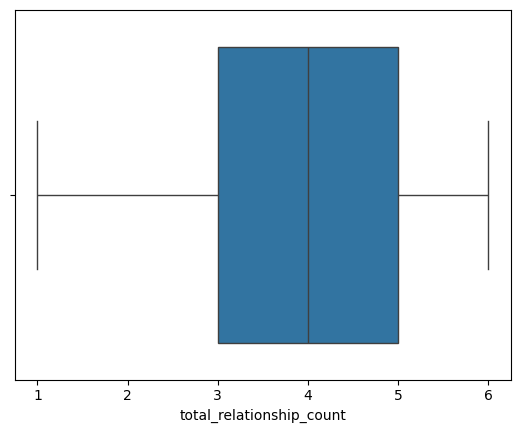

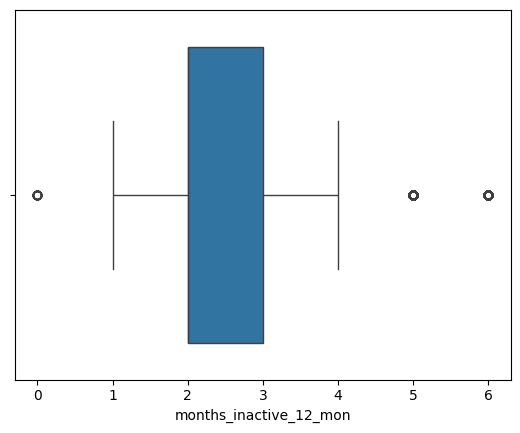

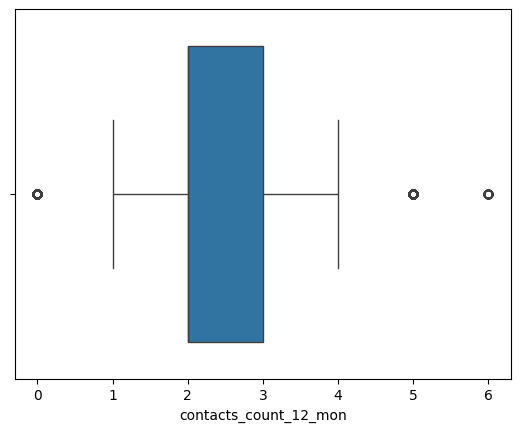

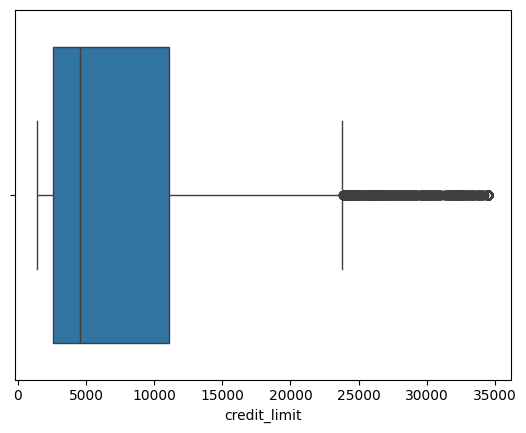

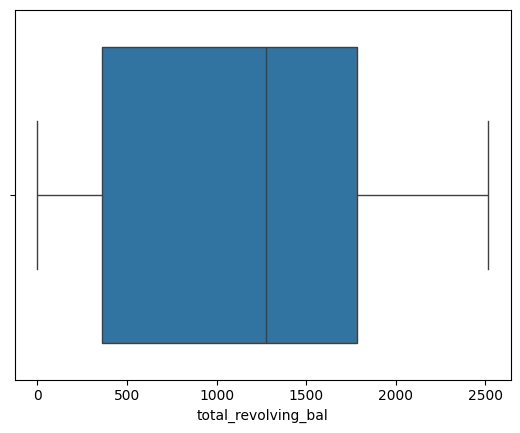

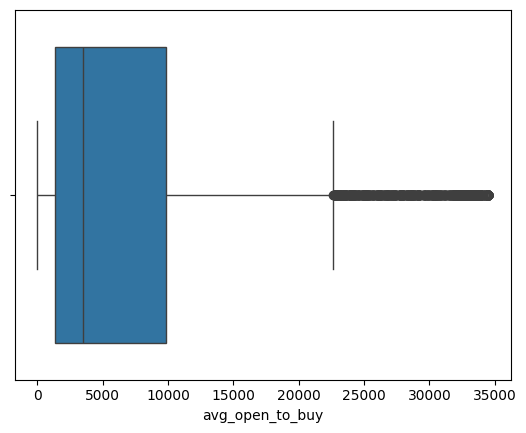

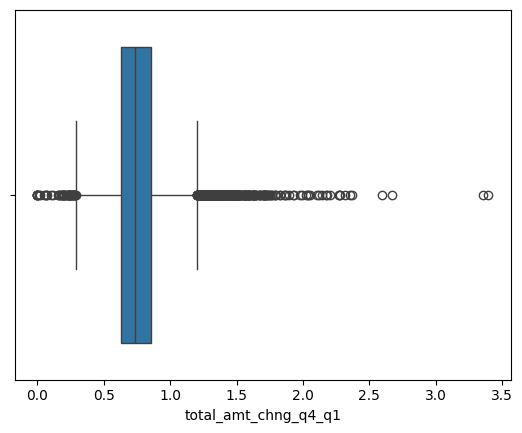

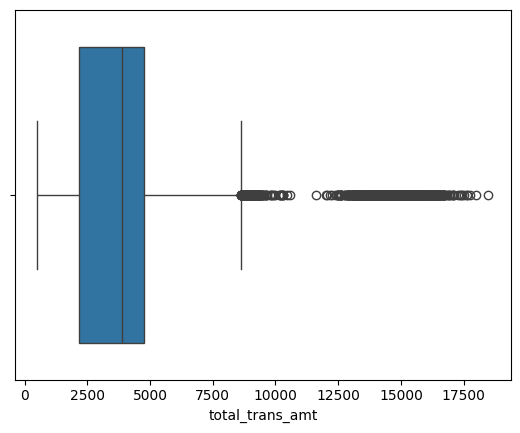

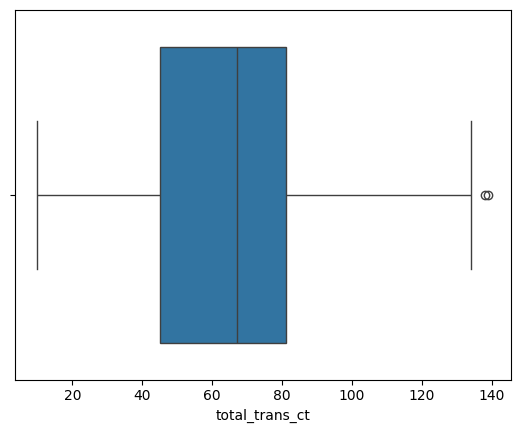

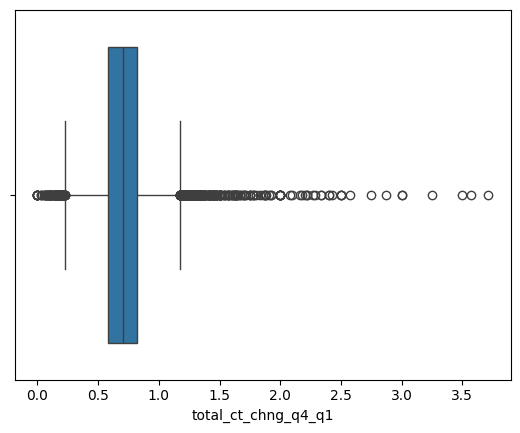

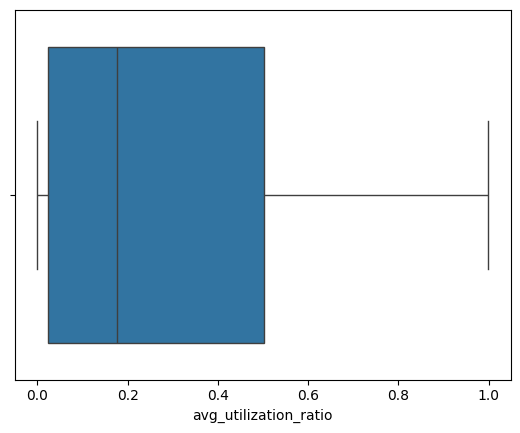

In [ ]:
numeric_cols = df.select_dtypes(include=np.number).columns
for col in numeric_cols:
    sns.boxplot(x=df[col])
    plt.show()

In [ ]:
df["customer_value"] = (
    df["total_trans_amt"] *
    df["total_trans_ct"]
)

In [ ]:
df["customer_value"]

,customer_value
0,48048
1,42603
2,37740
3,23420
4,22848
...,...
10122,1810692
10123,604716
10124,617460
10125,520490


In [ ]:
df["credit_used"] = (
    df["credit_limit"] -
    df["avg_open_to_buy"]
)

In [ ]:
df['credit_used']

,credit_used
0,777.0
1,864.0
2,0.0
3,2517.0
4,0.0
...,...
10122,1851.0
10123,2186.0
10124,0.0
10125,0.0


In [ ]:
numeric_df = df.select_dtypes(
    include=np.number
)

In [ ]:
numeric_df

,clientnum,customer_age,dependent_count,months_on_book,total_relationship_count,months_inactive_12_mon,contacts_count_12_mon,credit_limit,total_revolving_bal,avg_open_to_buy,total_amt_chng_q4_q1,total_trans_amt,total_trans_ct,total_ct_chng_q4_q1,avg_utilization_ratio,customer_value,credit_used
0,768805383,45,3,39,5,1,3,12691.0,777,11914.0,1.335,1144,42,1.625,0.061,48048,777.0
1,818770008,49,5,44,6,1,2,8256.0,864,7392.0,1.541,1291,33,3.714,0.105,42603,864.0
2,713982108,51,3,36,4,1,0,3418.0,0,3418.0,2.594,1887,20,2.333,0.000,37740,0.0
3,769911858,40,4,34,3,4,1,3313.0,2517,796.0,1.405,1171,20,2.333,0.760,23420,2517.0
4,709106358,40,3,21,5,1,0,4716.0,0,4716.0,2.175,816,28,2.500,0.000,22848,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10122,772366833,50,2,40,3,2,3,4003.0,1851,2152.0,0.703,15476,117,0.857,0.462,1810692,1851.0
10123,710638233,41,2,25,4,2,3,4277.0,2186,2091.0,0.804,8764,69,0.683,0.511,604716,2186.0
10124,716506083,44,1,36,5,3,4,5409.0,0,5409.0,0.819,10291,60,0.818,0.000,617460,0.0
10125,717406983,30,2,36,4,3,3,5281.0,0,5281.0,0.535,8395,62,0.722,0.000,520490,0.0


In [ ]:
numeric_df = numeric_df.drop(
    columns=["clientnum"]
)

In [ ]:
scaler = StandardScaler()

scaled_data = scaler.fit_transform(
    numeric_df
)

In [ ]:
from sklearn.cluster import KMeans

wcss = []

for k in range(1,11):

    model = KMeans(
        n_clusters=k,
        random_state=42
    )

    model.fit(scaled_data)

    wcss.append(model.inertia_)

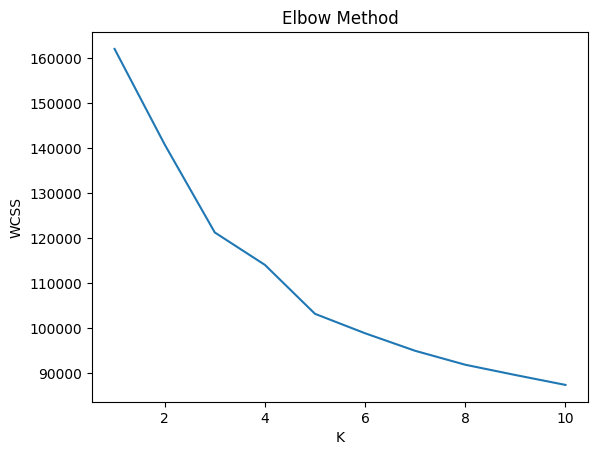

In [ ]:
plt.plot(range(1,11), wcss)
plt.xlabel("K")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

In [ ]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42
)

clusters = kmeans.fit_predict(
    scaled_data
)

df["Cluster"] = clusters

In [ ]:
df['Cluster']

,Cluster
0,3
1,0
2,3
3,0
4,0
...,...
10122,2
10123,0
10124,3
10125,3


In [ ]:
from sklearn.decomposition import PCA

pca = PCA(
    n_components=2
)

pca_result = pca.fit_transform(
    scaled_data
)

df["PCA1"] = pca_result[:,0]
df["PCA2"] = pca_result[:,1]

In [ ]:
import plotly.express as px

fig = px.scatter(
    df,
    x="PCA1",
    y="PCA2",
    color="Cluster",
    hover_data=["customer_age"]
)

fig.show()

In [ ]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(
    eps=0.8,
    min_samples=10
)

db_clusters = dbscan.fit_predict(
    scaled_data
)

df["DBSCAN"] = db_clusters

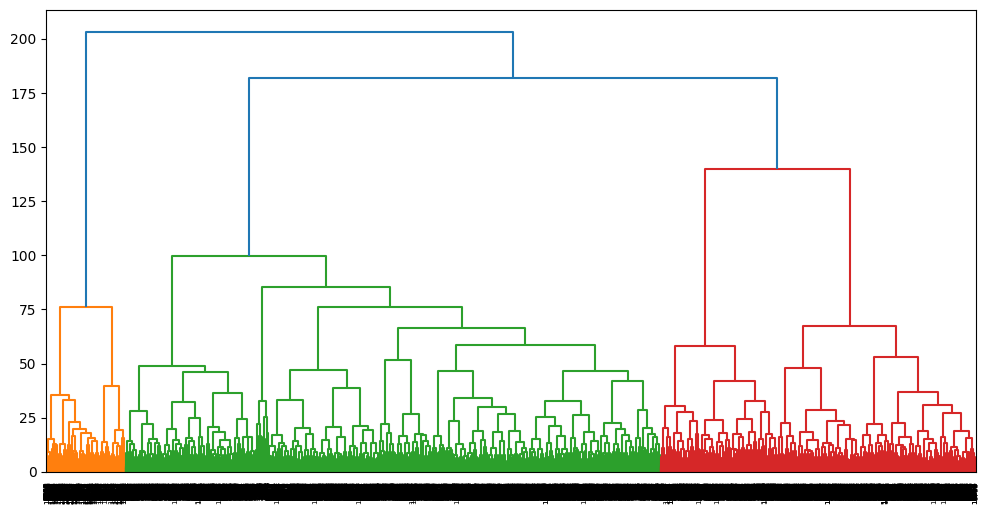

In [ ]:
from scipy.cluster.hierarchy import dendrogram
from scipy.cluster.hierarchy import linkage

linked = linkage(
    scaled_data,
    method='ward'
)

plt.figure(figsize=(12,6))

dendrogram(linked)

plt.show()

In [ ]:
from sklearn.manifold import TSNE

tsne = TSNE(
    n_components=2,
    random_state=42
)

tsne_result = tsne.fit_transform(
    scaled_data
)

df["TSNE1"] = tsne_result[:,0]
df["TSNE2"] = tsne_result[:,1]

In [ ]:
px.scatter(
    df,
    x="TSNE1",
    y="TSNE2",
    color="Cluster"
)

In [ ]:
from sklearn.ensemble import IsolationForest

iso = IsolationForest(
    contamination=0.02,
    random_state=42
)

df["Anomaly"] = iso.fit_predict(
    scaled_data
)

In [ ]:
px.scatter(
    df,
    x="PCA1",
    y="PCA2",
    color="Anomaly"
)

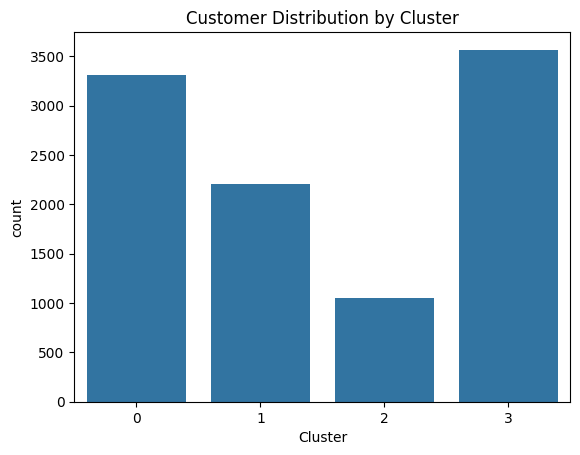

In [ ]:
sns.countplot(
    x="Cluster",
    data=df
)

plt.title(
    "Customer Distribution by Cluster"
)

plt.show()

## Cluster Analysis

In [ ]:
cluster_summary = df.groupby('Cluster')[numeric_df.columns].mean()
display(cluster_summary)

,customer_age,dependent_count,months_on_book,total_relationship_count,months_inactive_12_mon,contacts_count_12_mon,credit_limit,total_revolving_bal,avg_open_to_buy,total_amt_chng_q4_q1,total_trans_amt,total_trans_ct,total_ct_chng_q4_q1,avg_utilization_ratio,customer_value,credit_used
Cluster,,,,,,,,,,,,,,,,
0,41.341198,2.691470,31.436177,4.007562,2.278887,2.399274,5102.996491,1649.157290,3453.839201,0.794959,3664.609498,64.161827,0.757467,0.475497,2.574094e+05,1649.157290
1,54.853515,1.633560,43.480272,4.146032,2.361451,2.433560,6202.493424,1620.156916,4582.336508,0.746644,3193.393197,57.513379,0.707807,0.424145,2.125779e+05,1620.156916
2,45.432793,2.346997,35.207817,2.194471,2.201144,2.162059,16438.097235,1425.095329,15013.001907,0.772188,12792.783603,104.829361,0.727090,0.158495,1.369337e+06,1425.095329
3,45.937202,2.466498,35.635548,3.901598,2.427530,2.606953,11108.838436,352.209980,10756.628455,0.732102,3370.877768,58.290440,0.668646,0.030937,2.209995e+05,352.209980


### Who are the bank's customer segments?

Based on the K-Means clustering (with 4 clusters) and the summary statistics above, we can describe the customer segments:

*   **Cluster 0:** This cluster has a moderate customer age, a high dependent count, and generally moderate credit limits and usage. They have lower total transaction amounts and counts compared to other active clusters.
*   **Cluster 1:** This cluster appears to represent customers with lower overall engagement. They have significantly lower credit limits, total revolving balance, and average utilization ratio. Their total transaction amounts and counts are also very low. They also have a slightly higher `months_inactive_12_mon` and `contacts_count_12_mon`.
*   **Cluster 2:** These customers are highly engaged with high credit limits, high total transaction amounts, and high transaction counts. They also have a very high `customer_value` and a higher `avg_utilization_ratio`.
*   **Cluster 3:** This cluster shows a moderate to high level of activity, with a good balance of credit usage and transaction activity. They have a higher `credit_limit` and `avg_open_to_buy` than Cluster 0, but lower transaction metrics than Cluster 2.

To better define these segments, one would typically examine the average values for *all* relevant features (numerical and potentially one-hot encoded categorical) within each cluster. However, based on the numeric data alone, these are the general trends.

### How many customer groups exist?

Based on the K-Means clustering, **4 customer groups** (clusters) exist, as specified by `n_clusters=4` in the K-Means model.

### Which group is most valuable?

From the `cluster_summary` table (specifically the `customer_value` row):

**Cluster 2** appears to be the most valuable group, with the highest average `customer_value` (approximately 1,440,000). This is supported by their high `total_trans_amt` and `total_trans_ct`.

### Which group is least active?

From the `cluster_summary` table, considering `months_inactive_12_mon` and `contacts_count_12_mon`:

**Cluster 1** shows higher average `months_inactive_12_mon` and `contacts_count_12_mon` along with very low `total_trans_amt` and `total_trans_ct`. This indicates they are the least active group.

### Are there abnormal customers?

Yes, the Isolation Forest model identified abnormal customers. The `df["Anomaly"]` column contains `1` for normal points and `-1` for anomalies. To see the count of anomalies:


In [ ]:
display(df['Anomaly'].value_counts())
num_anomalies = (df['Anomaly'] == -1).sum()
print(f"Number of abnormal customers identified: {num_anomalies}")

,count
Anomaly,
1,9924
-1,203


Number of abnormal customers identified: 203


These abnormal customers are typically outliers that deviate significantly from the rest of the data, potentially indicating fraudulent activity or unusual behavior. The `px.scatter` plot with `PCA1`, `PCA2`, and `color="Anomaly"` visually highlights these points.

### What does customer behavior look like in 2D space?

The customer behavior in 2D space is visualized using PCA and t-SNE:

*   **PCA (Principal Component Analysis):** The `px.scatter` plot of `PCA1` vs `PCA2` colored by `Cluster` shows how the clusters separate based on the two principal components that capture the most variance in the data. You can observe distinct groupings for the different K-Means clusters, indicating that the clusters are somewhat separable in this reduced dimension.

*   **t-SNE (t-Distributed Stochastic Neighbor Embedding):** The `px.scatter` plot of `TSNE1` vs `TSNE2` colored by `Cluster` provides another 2D representation. t-SNE is particularly good at preserving local structures, meaning that customers who are similar in high-dimensional space remain close in the 2D t-SNE plot. This plot typically reveals more intricate and well-defined clusters than PCA, showing more clearly how different customer segments are formed based on their behavior.

### What is the optimal number of clusters?

Based on the "Elbow Method" plot, which plots WCSS (Within-Cluster Sum of Squares) against the number of clusters (K):

There isn't a perfectly sharp elbow, but a common choice for an 'elbow' would be around **K=3 or K=4**. The curve starts to flatten out significantly after these points, suggesting that adding more clusters beyond this doesn't yield substantial improvements in reducing WCSS. The K-Means model was trained with 4 clusters, which is a reasonable choice based on this method.

### How are customers distributed across clusters?

The customer distribution across clusters is shown by the `sns.countplot` plot titled "Customer Distribution by Cluster".

This plot visually represents the number of customers assigned to each of the 4 K-Means clusters. By looking at the bar heights, you can quickly see which clusters have more members and which have fewer, giving an immediate understanding of the size of each customer segment. For instance, if one bar is significantly taller than others, it means that cluster represents a larger portion of the customer base.

In [ ]:
# Save clustered dataset

output_file = "BankChurners_Clustered.csv"

df.to_csv(output_file, index=False)

print(f"Dataset saved as {output_file}")

Dataset saved as BankChurners_Clustered.csv


In [ ]:
fig.write_html(
    "Customer_Clusters.html"
)

print("HTML file saved successfully.")

HTML file saved successfully.


In [ ]:
tsne_fig = px.scatter(
    df,
    x="TSNE1",
    y="TSNE2",
    color="Cluster",
    title="t-SNE Customer Clusters"
)

tsne_fig.write_html(
    "TSNE_Clusters.html"
)

In [ ]:
anomaly_fig = px.scatter(
    df,
    x="PCA1",
    y="PCA2",
    color="Anomaly",
    title="Isolation Forest Anomaly Detection"
)

anomaly_fig.write_html(
    "Anomaly_Detection.html"
)

In [ ]:
import os

os.makedirs("outputs", exist_ok=True)

df.to_csv(
    "outputs/BankChurners_Clustered.csv",
    index=False
)

fig.write_html(
    "outputs/Customer_Clusters.html"
)

tsne_fig.write_html(
    "outputs/TSNE_Clusters.html"
)

anomaly_fig.write_html(
    "outputs/Anomaly_Detection.html"
)

print("All files saved inside outputs folder.")

All files saved inside outputs folder.
